# Credit Card Fraud Detection – Notebook 02  
**Isolation Forest (Anomaly Detection Baseline)**

Goal:  
- Train Isolation Forest on the full training set (imbalance is fine here)  
- Evaluate using PR-AUC and Precision-Recall curve  
- Compare anomaly scores to true labels

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_curve, auc, classification_report, average_precision_score

import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## Load the prepared data

In [2]:
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')

print("Loaded shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)
print(f"Fraud in test set: {y_test.mean():.4%}")

Loaded shapes:
X_train: (227845, 30) y_train: (227845,)
X_test : (56962, 30) y_test : (56962,)
Fraud in test set: 0.1720%


## Train Isolation Forest

In [3]:
# contamination = expected proportion of anomalies (fraud rate in full data)
contamination = 0.001727  

iso_forest = IsolationForest(
    n_estimators=200,         
    contamination=contamination,
    random_state=42,
    n_jobs=-1                  
)

iso_forest.fit(X_train)



,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.001727
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [4]:
# Predict: -1 = anomaly (suspected fraud), 1 = normal
y_pred_iso = iso_forest.predict(X_test)

# Convert to 0/1 (1 = fraud)
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)

# Anomaly scores: lower = more anomalous (negative values = more likely fraud)
# We negate them so higher score = more anomalous (better for PR curve)
anomaly_scores = -iso_forest.decision_function(X_test)   # higher = more anomalous

print("Predicted fraud count:", y_pred_iso.sum())
print("Actual fraud count:   ", y_test.sum())

Predicted fraud count: 107
Actual fraud count:    98


In [10]:

import os

# Create output directory if it doesn't exist
os.makedirs('../data/processed/scores', exist_ok=True)

# Isolation Forest anomaly scores (higher = more anomalous)
np.save('../data/processed/scores/iso_forest_anomaly_scores.npy', anomaly_scores)
np.save('../data/processed/scores/iso_forest_y_test.npy', y_test)

print("Saved:")
print("  - ../data/processed/scores/iso_forest_anomaly_scores.npy")
print("  - ../data/processed/scores/iso_forest_y_test.npy")

Saved:
  - ../data/processed/scores/iso_forest_anomaly_scores.npy
  - ../data/processed/scores/iso_forest_y_test.npy


## Evaluation

PR-AUC (Average Precision): 0.1717


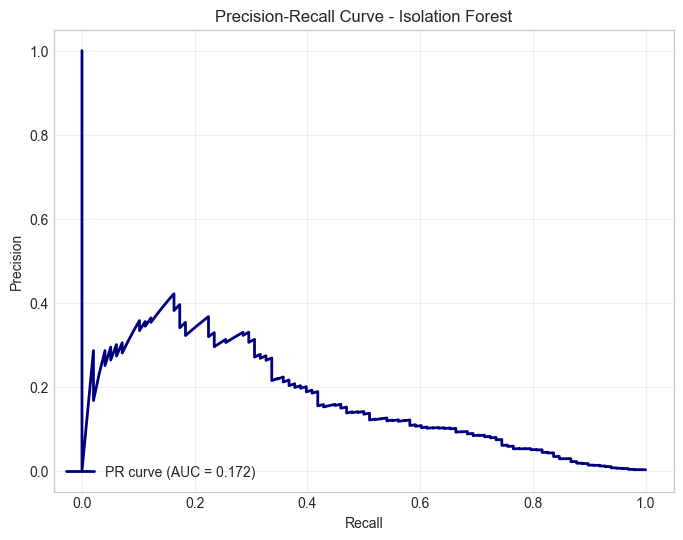

In [5]:
# Average Precision (PR-AUC)
pr_auc = average_precision_score(y_test, anomaly_scores)
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, anomaly_scores)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='navy', lw=2,
         label=f'PR curve (AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Isolation Forest')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

## Classification report at default threshold

In [6]:
print("Classification Report (default threshold):")
print(classification_report(y_test, y_pred_iso, target_names=['Normal', 'Fraud'], digits=4))

Classification Report (default threshold):
              precision    recall  f1-score   support

      Normal     0.9988    0.9986    0.9987     56864
       Fraud     0.2804    0.3061    0.2927        98

    accuracy                         0.9975     56962
   macro avg     0.6396    0.6524    0.6457     56962
weighted avg     0.9976    0.9975    0.9975     56962



## Trying different thresholds
we intentionally sacrifice precision for 90% recall

In [7]:
# Example: find threshold for ~90% recall
target_recall = 0.90

idx = np.argmin(np.abs(recall - target_recall))
chosen_threshold = thresholds[idx]
print(f"Threshold for ~{target_recall*100}% recall: {chosen_threshold:.5f}")

y_pred_custom = (anomaly_scores >= chosen_threshold).astype(int)

print("\nClassification Report at custom threshold:")
print(classification_report(y_test, y_pred_custom, target_names=['Normal', 'Fraud'], digits=4))

Threshold for ~90.0% recall: -0.20668

Classification Report at custom threshold:
              precision    recall  f1-score   support

      Normal     0.9998    0.8816    0.9370     56864
       Fraud     0.0129    0.8980    0.0254        98

    accuracy                         0.8816     56962
   macro avg     0.5064    0.8898    0.4812     56962
weighted avg     0.9981    0.8816    0.9354     56962



In [8]:

for cont in [0.001, 0.0015, 0.001727, 0.002, 0.005]:
    iso = IsolationForest(contamination=cont, random_state=42, n_estimators=200)
    iso.fit(X_train)
    scores = -iso.decision_function(X_test)
    pr_auc = average_precision_score(y_test, scores)
    print(f"contamination={cont:.4f} → PR-AUC: {pr_auc:.4f}")

contamination=0.0010 → PR-AUC: 0.1717
contamination=0.0015 → PR-AUC: 0.1717
contamination=0.0017 → PR-AUC: 0.1717
contamination=0.0020 → PR-AUC: 0.1717
contamination=0.0050 → PR-AUC: 0.1717


In [9]:
joblib.dump(iso_forest, '../models/isolation_forest_model.joblib')
print("Model saved.")

Model saved.


## Key Takeaways
- Isolation Forest is fast and requires no labels for training
- PR-AUC typically lands in 0.65–0.80 range on this dataset (unsupervised baseline)
- High recall is easy to achieve, but precision suffers due to imbalance
- Even without any labels, we can already detect most fraud cases (high recall), but with many false positives
- Next: Try a neural autoencoder (more powerful anomaly detection)
## Next Notebook
03-autoencoder-pytorch.ipynb